
# GONG PFSS extrapolation

Calculating PFSS solution for a GONG synoptic magnetic field map.


In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import astropy.constants as const
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a

from sunkit_magex import pfss

# # Set the data directory path
# DATA_DIR = Path.cwd().parent / 'data'
# DATA_DIR = DATA_DIR.resolve() # resolve the relative path to the absolute path
# os.makedirs(DATA_DIR, exist_ok=True)
# Check sunpy's default download directory
# print(f"SunPy default download directory: {sunpy.config.get('downloads', 'download_dir')}")
# sunpy.config.set('downloads', 'download_dir', DATA_DIR)
# print(f"Set SunPy download directory to: {sunpy.config.get('downloads', 'download_dir')}")

/disk/anaconda/xw2/miniconda3/envs/sunpy_7/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load a GONG magnetic field map.



In [4]:
# Download GONG sample data to the specified data directory
gong_fname = pfss.sample_data.get_gong_map()

gong_map = sunpy.map.Map(gong_fname)

The PFSS solution is calculated on a regular 3D grid in (phi, s, rho), where
rho = ln(r), and r is the standard spherical radial coordinate. We need to
define the number of rho grid points, and the source surface radius.



In [5]:
nrho = 35
rss = 2.5

From the boundary condition, number of radial grid points, and source
surface, we now construct an Input object that stores this information.



In [6]:
pfss_in = pfss.Input(gong_map, nrho, rss)

Using the Input object, plot the input field.



2026-01-16 12:00:45 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


Text(0.5, 1.0, 'Input field')

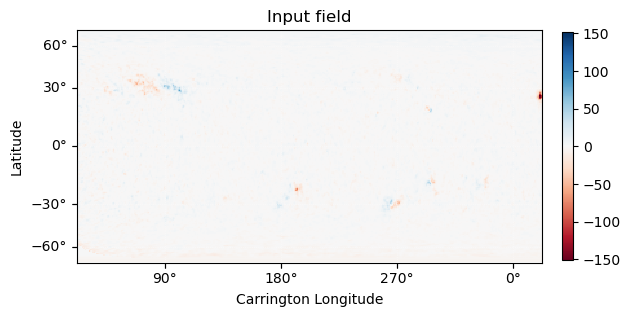

In [7]:
input_map = pfss_in.map
fig = plt.figure()
ax = fig.add_subplot(projection=input_map)
im = input_map.plot(axes=ax)
plt.colorbar(im, ax=ax, fraction=0.023, pad=0.04)
ax.set_title('Input field')

Now calculate the PFSS solution.



In [9]:
pfss_out = pfss.pfss(pfss_in)

Using the Output object we can plot the source surface field, and the
polarity inversion line.



Text(0.5, 1.0, 'Source surface magnetic field')

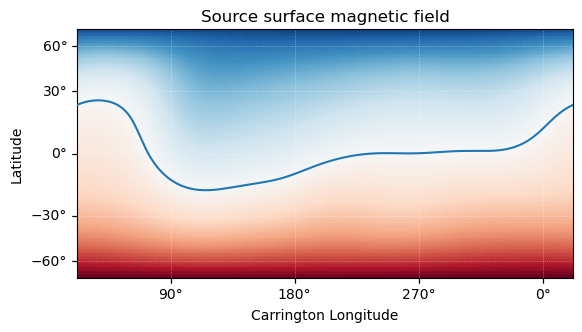

In [10]:
ss_br = pfss_out.source_surface_br

fig = plt.figure()
ax = fig.add_subplot(projection=ss_br)

ss_br.plot(axes=ax)
# Plot the polarity inversion line
ax.plot_coord(pfss_out.source_surface_pils[0])
# plt.colorbar()
ax.set_title('Source surface magnetic field')

It is also easy to plot the magnetic field at an arbitrary height within
the PFSS solution.



In [27]:
help(pfss_out)

Help on Output in module sunkit_magex.pfss.output object:

class Output(builtins.object)
 |  Output(alr, als, alp, grid, input_map=None)
 |
 |  Output of PFSS modelling.
 |
 |  Parameters
 |  ----------
 |  alr :
 |      Vector potential * grid spacing in radial direction.
 |  als :
 |      Vector potential * grid spacing in elevation direction.
 |  alp :
 |      Vector potential * grid spacing in azimuth direction.
 |  grid : Grid
 |      Grid that the output was calculated on.
 |  input_map : sunpy.map.GenericMap
 |      The input map.
 |
 |  Notes
 |  -----
 |  Instances of this class are intended to be created by `sunkit_magex.pfss.pfss`, and
 |  not by users.
 |
 |  Methods defined here:
 |
 |  __init__(self, alr, als, alp, grid, input_map=None)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  get_bvec(self, coords, out_type='spherical')
 |      Interpolate magnetic vectors at arbitrary coordinates.
 |
 |      Parameters
 |      ----------
 |      coor

Text(0.5, 1.0, '$B_{r}$ at r=1.07$r_{\\odot}$')

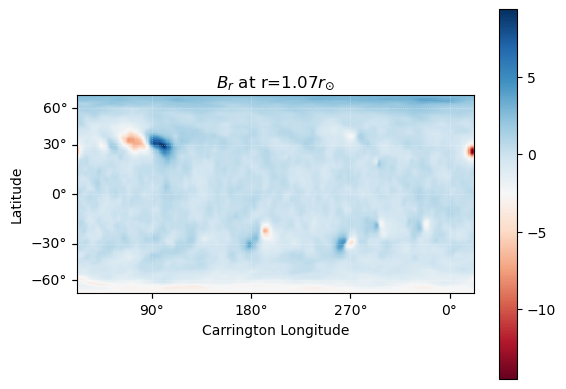

In [25]:
# Get the radial magnetic field at a given height
ridx = 2
br = pfss_out.bc[0][:, :, ridx]
# Create a sunpy Map object using output WCS
br = sunpy.map.Map(br.T, pfss_out.source_surface_br.wcs)
# Get the radial coordinate
r = np.exp(pfss_out.grid.rc[ridx])

fig = plt.figure()
ax = fig.add_subplot(projection=br)

br.plot(cmap='RdBu')
plt.colorbar()
ax.set_title('$B_{r}$ ' + f'at r={r:.2f}' + '$r_{\\odot}$')

Finally, using the 3D magnetic field solution we can trace some field lines.
In this case 64 points equally gridded in theta and phi are chosen and
traced from the source surface outwards.



/disk/anaconda/xw2/miniconda3/envs/sunpy_7/lib/python3.14/site-packages/sunkit_magex/pfss/tracing.py:176: UserWarning: At least one field line ran out of steps during tracing.
You should probably increase max_steps (currently set to auto) and try again.
  warnings.warn(


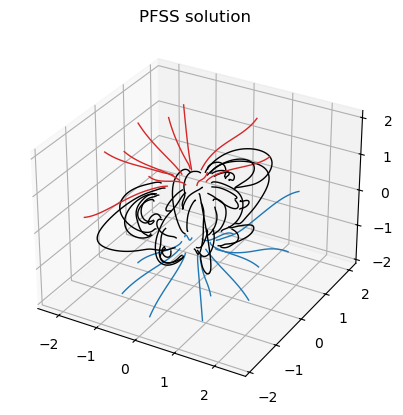

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

tracer = pfss.tracing.PerformanceTracer()
r = 1.2 * const.R_sun
lat = np.linspace(-np.pi / 2, np.pi / 2, 8, endpoint=False)
lon = np.linspace(0, 2 * np.pi, 8, endpoint=False)
lat, lon = np.meshgrid(lat, lon, indexing='ij')
lat, lon = lat.ravel() * u.rad, lon.ravel() * u.rad

seeds = SkyCoord(lon, lat, r, frame=pfss_out.coordinate_frame)
field_lines = tracer.trace(seeds, pfss_out)
for field_line in field_lines:
    color = {0: 'black', -1: 'tab:blue', 1: 'tab:red'}.get(field_line.polarity)
    coords = field_line.coords
    coords.representation_type = 'cartesian'
    ax.plot(coords.x / const.R_sun,
            coords.y / const.R_sun,
            coords.z / const.R_sun,
            color=color, linewidth=1)
ax.set_title('PFSS solution')

plt.show()